In [1]:
import sys, os
sys.path.append(os.path.abspath('D:/projects-312/dynamodelx/src'))

In [ ]:
from dynamodelx import BnnBinaryClassifier
from dynamodelx.plots import draw_plots
from sklearn.datasets import load_breast_cancer
import numpy as np
np.set_printoptions(suppress=True)
X, y = load_breast_cancer(return_X_y=True)

In [ ]:
classifier = BnnBinaryClassifier(
                model_size = 'small',
                input_dim = X.shape[1],
                device = 'cuda',
                hidden_activation = 'relu',
                optimizer = 'adam',
                mc_samples = 20,
                custom_architecture = None,
                return_metrics = True,
                auto_build  = True
)

Model Configuration:

  Model Size:         small
  Input Dimension:    30
  Loss                Negative ELBO Loss (KL(q(w)||p(w)) + BCE)
  Device:             cuda
  Hidden Activation:  relu
  Optimizer:          adam
  Custom Architecture:None

Building the model ...

        Model Summary        
Layer (name)                   Shape                Param #   
--------------------------------------------------------------
weight_mu.0                    (64, 30)             1920      
weight_mu.1                    (32, 64)             2048      
weight_mu.2                    (1, 32)              32        
weight_log_std.0               (64, 30)             1920      
weight_log_std.1               (32, 64)             2048      
weight_log_std.2               (1, 32)              32        
bias_mu.0                      (64,)                64        
bias_mu.1                      (32,)                32        
bias_mu.2                      (1,)                 1         
bias_

In [ ]:
performance = classifier.train(
    X=X,
    y=y,
    epochs=50,
    learning_rate=0.01,
    momentum=None,
    val_size=0.2,
    test_size=0.1,
    batch_size=32,
    threshold=0.7,
    temp_lr=0.01,
    temp_epochs=100
)

Average train loss per sample : 1.24 
Average validation loss per sample : 0.08
Average Test Loss: 0.02

Expected Calibration Error : 0.02


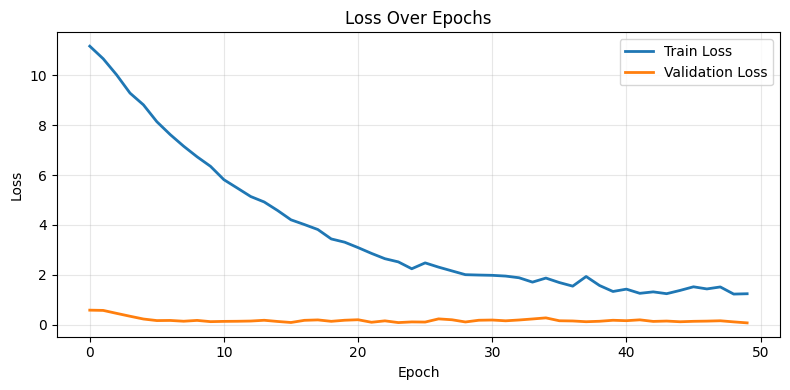

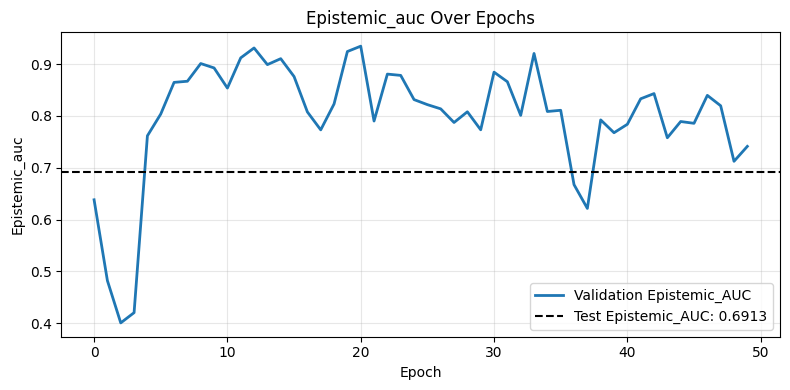

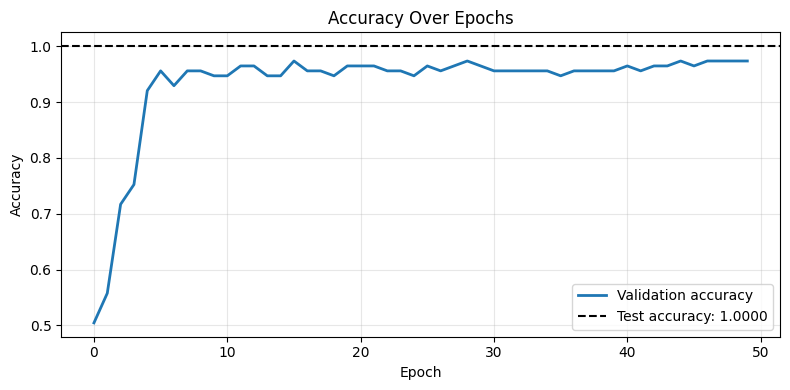

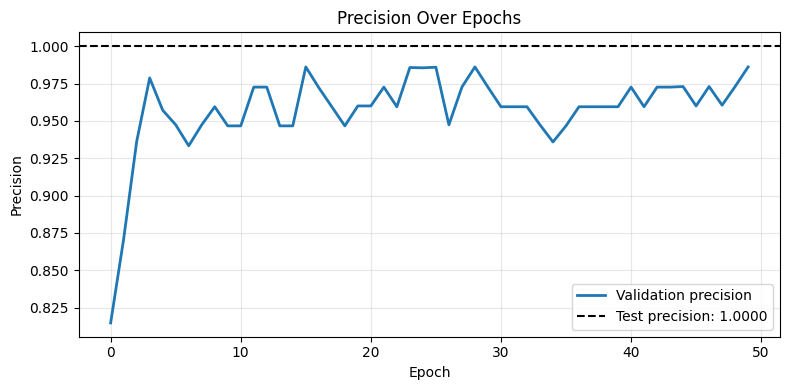

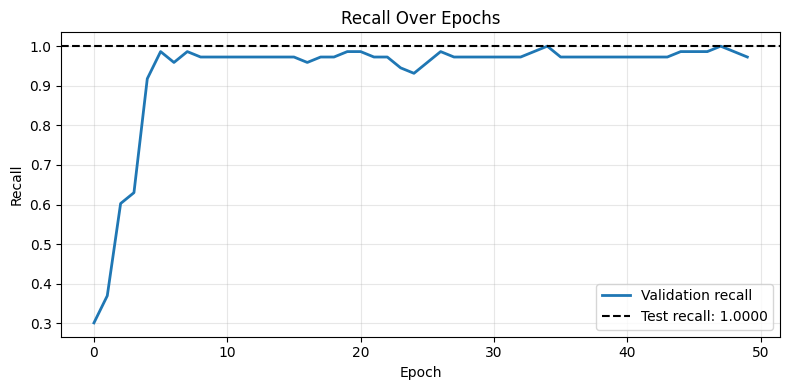

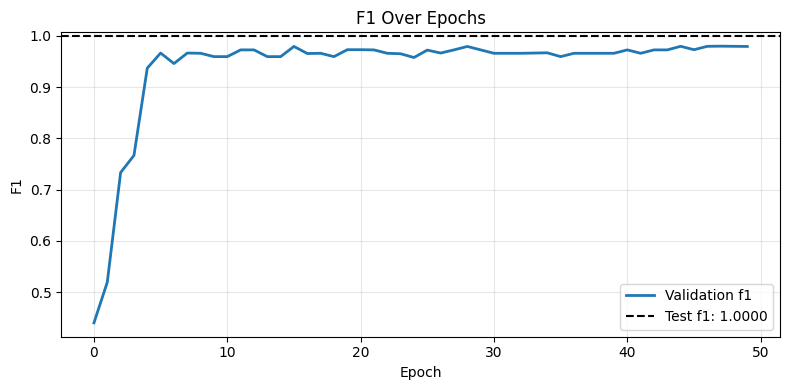

In [ ]:
draw_plots(performance=performance)

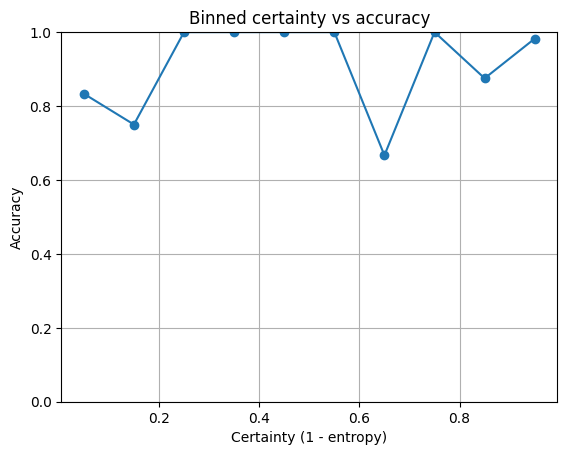

In [ ]:
import matplotlib.pyplot as plt
x = X[:300]
y_true = y[:300]

y_pred, epistemic_std, certainity = classifier.predict(x, mc_samples=20)

bins = np.linspace(0, 1, 11)
bin_idx = np.digitize(certainity, bins) - 1

accuracy_per_bin = []
bin_centers = (bins[:-1] + bins[1:]) / 2

for i in range(len(bin_centers)):
    mask = bin_idx == i
    if mask.sum() > 0:
        accuracy_per_bin.append((y_true[mask] == y_pred[mask]).mean())
    else:
        accuracy_per_bin.append(np.nan)

plt.plot(bin_centers, accuracy_per_bin, marker='o')
plt.xlabel("Certainty (1 - entropy)")
plt.ylabel("Accuracy")
plt.title("Binned certainty vs accuracy")
plt.ylim(0,1)
plt.grid(True)
plt.show()



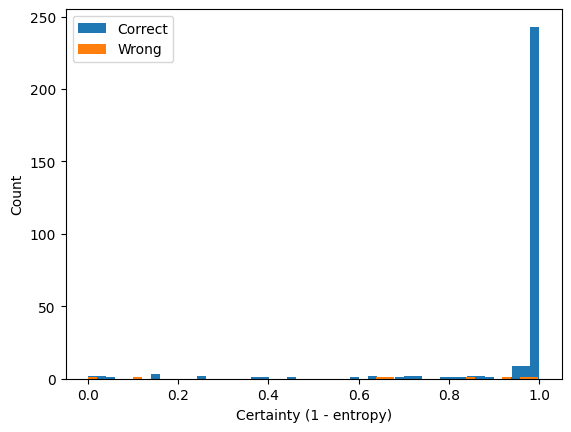

In [ ]:
plt.hist(certainity[y_true==y_pred], bins=50, alpha=1, label="Correct")
plt.hist(certainity[y_true!=y_pred], bins=50, alpha=1, label="Wrong")
plt.xlabel("Certainty (1 - entropy)")
plt.ylabel("Count")
plt.legend()
plt.show()


In [ ]:
classifier.save(parameters_path='breast_cancer_param.pt', arguments_path='breast_cancer_args.pt')

Model's state successfully saved to: breast_cancer_param.pt
Model's architecture successfully saved to: breast_cancer_args.pt


In [ ]:
classifier = BnnBinaryClassifier.load(parameters_path='breast_cancer_param.pt', arguments_path='breast_cancer_args.pt')
label, epistemic_std, certainty = classifier.predict(X[:1])
print(f'Model labeled {label}, having modeling uncertainty of {epistemic_std:.6f} . It is {certainty*100:.0f}% confident on the prediction')

Model Configuration:

  Model Size:         small
  Input Dimension:    30
  Loss                Negative ELBO Loss (KL(q(w)||p(w)) + BCE)
  Device:             cuda
  Hidden Activation:  relu
  Optimizer:          adam
  Custom Architecture:None

Building the model ...

        Model Summary        
Layer (name)                   Shape                Param #   
--------------------------------------------------------------
weight_mu.0                    (64, 30)             1920      
weight_mu.1                    (32, 64)             2048      
weight_mu.2                    (1, 32)              32        
weight_log_std.0               (64, 30)             1920      
weight_log_std.1               (32, 64)             2048      
weight_log_std.2               (1, 32)              32        
bias_mu.0                      (64,)                64        
bias_mu.1                      (32,)                32        
bias_mu.2                      (1,)                 1         
bias_